# Predicting Highly-Rated Android Apps 📱⭐

**Goal:** Using Google Play Store metadata (genre, price, content rating, popularity signals, monetization), predict whether an app is **highly rated** (score ≥ 4.2) or not.

**Notebook flow:**
1. Load & inspect the data
2. Clean & handle missing values
3. Feature engineering
4. Exploratory Data Analysis (EDA)
5. Train/test split
6. Build & evaluate ML model (Gradient Boosting Classifier)
7. Feature importance
8. Conclusion

This notebook is written to be **beginner-friendly** — every step is explained in simple terms.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load the Dataset
We only load the columns we actually need to keep things fast and memory-friendly.

In [2]:
# Loading only the relevant columns from apps.csv
cols = ['app_id', 'score', 'ratings', 'reviews', 'min_installs', 'price',
        'free', 'genre', 'content_rating', 'ad_supported',
        'contains_ads', 'in_app_purchases']

df = pd.read_csv('apps.csv', usecols=cols)
print("Shape of data:", df.shape)
df.head()

Shape of data: (11176, 12)


,app_id,min_installs,score,ratings,reviews,price,free,genre,content_rating,ad_supported,contains_ads,in_app_purchases
0,com.droid4you.application.wallet,1.000000e+07,4.602770,376251.0,7477.0,0.0,True,Finance,Everyone,False,False,True
1,com.freeman.moneymanager,5.000000e+06,4.868132,284764.0,921.0,0.0,True,Finance,Teen,True,True,True
2,com.picsart.studio,1.000000e+09,4.032339,12207068.0,445242.0,0.0,True,Photography,Teen,True,True,True
3,com.colpit.diamondcoming.isavemoney,5.000000e+06,4.271907,51002.0,3147.0,0.0,True,Finance,Everyone,True,True,True
4,com.photoroom.app,1.000000e+08,4.684298,3881733.0,17581.0,0.0,True,Photography,Everyone,False,False,True


## 2. Handle Missing Values
`score`, `ratings`, and `reviews` have some missing values (apps with no ratings yet). We drop rows where `score` is missing, since that is our target.

In [3]:
print("Missing values before cleaning:\n", df.isna().sum())

# Drop rows where target (score) is missing
df = df.dropna(subset=['score']).reset_index(drop=True)
print("\nShape after dropping missing target rows:", df.shape)

Missing values before cleaning:
 app_id                 0
min_installs          31
score               2245
ratings             2245
reviews             2245
price                 31
free                   0
genre                  0
content_rating         0
ad_supported           0
contains_ads           0
in_app_purchases       0
dtype: int64

Shape after dropping missing target rows: (8931, 12)


## 3. Define the Target Variable
We define an app as **'Highly Rated'** if its score is **4.2 or above**, else **'Average/Low Rated'**. This threshold roughly splits the data while still meaning something to a real user.

target
1    5437
0    3494
Name: count, dtype: int64

Percentage of highly rated apps: 60.88 %


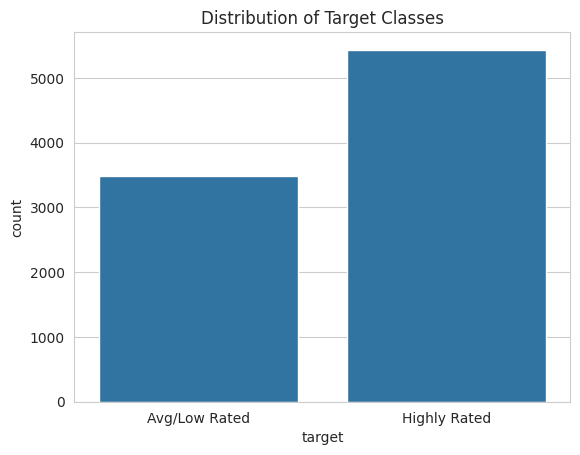

In [4]:
df['target'] = (df['score'] >= 4.2).astype(int)

print(df['target'].value_counts())
print("\nPercentage of highly rated apps:", round(df['target'].mean() * 100, 2), "%")

sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['Avg/Low Rated', 'Highly Rated'])
plt.title('Distribution of Target Classes')
plt.show()

## 4. Feature Engineering
- `reviews` and `ratings` are highly skewed (a few apps have millions), so we apply a **log transform**.
- `genre` and `content_rating` are text categories, so we **label encode** them.
- We deliberately **exclude** the `histogram` column (rating distribution) and `ratings`-derived score stats since they would leak the target directly.

In [5]:
# Log-transform skewed numeric features
df['log_reviews'] = np.log1p(df['reviews'].fillna(0))
df['log_ratings'] = np.log1p(df['ratings'].fillna(0))
df['log_installs'] = np.log1p(df['min_installs'].fillna(0))

# Encode categorical columns
le_genre = LabelEncoder()
le_content = LabelEncoder()
df['genre_enc'] = le_genre.fit_transform(df['genre'].astype(str))
df['content_enc'] = le_content.fit_transform(df['content_rating'].astype(str))

df[['log_reviews', 'log_ratings', 'log_installs', 'genre_enc', 'content_enc']].head()

,log_reviews,log_ratings,log_installs,genre_enc,content_enc
0,8.919721,12.838014,16.118096,18,1
1,6.826545,12.559420,15.424949,18,8
2,13.006375,16.317526,20.723266,31,8
3,8.054523,10.839640,15.424949,18,1
4,9.774631,15.171793,18.420681,31,1


## 5. Exploratory Data Analysis (EDA)
A quick look at how genre and monetization relate to ratings.

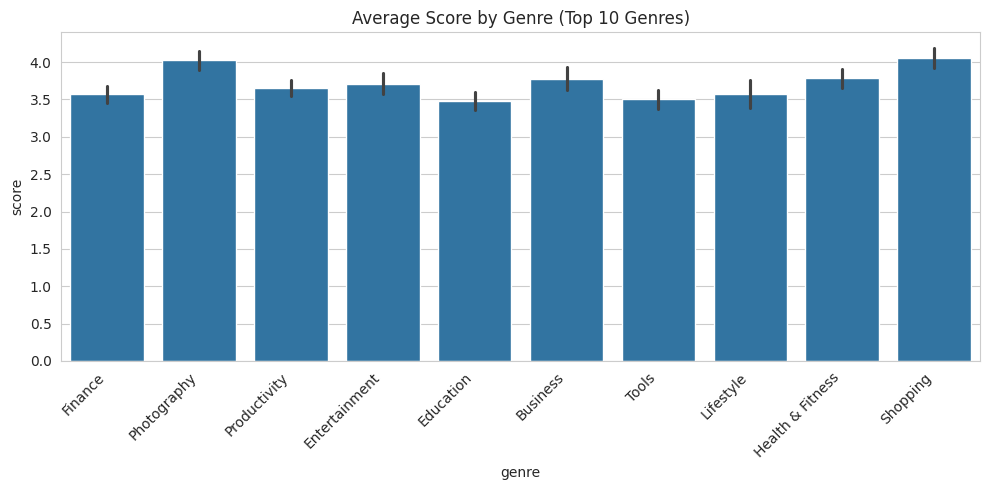

In [6]:
# Average score by top 10 genres
top_genres = df['genre'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.barplot(data=df[df['genre'].isin(top_genres)], x='genre', y='score', estimator=np.mean)
plt.xticks(rotation=45, ha='right')
plt.title('Average Score by Genre (Top 10 Genres)')
plt.tight_layout()
plt.show()

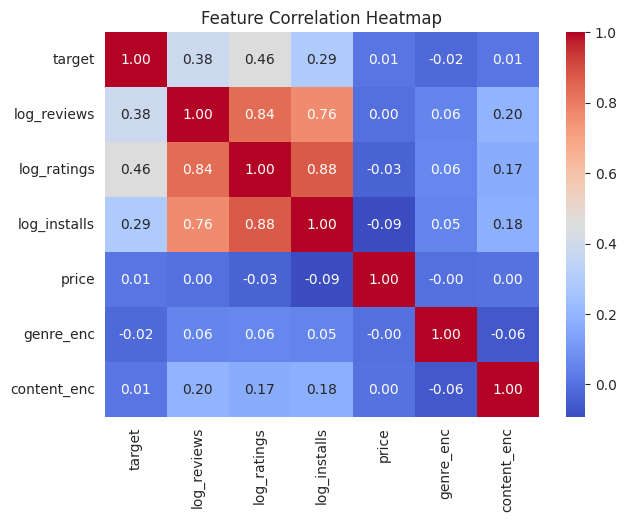

In [7]:
# Correlation heatmap of engineered numeric features
num_feats = ['target', 'log_reviews', 'log_ratings', 'log_installs', 'price', 'genre_enc', 'content_enc']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_feats].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Train/Test Split
We select our final feature set and split the data 80/20, using **stratify** to keep the class balance consistent in both sets.

In [8]:
features = ['log_reviews', 'log_ratings', 'log_installs', 'price', 'free',
            'genre_enc', 'content_enc', 'ad_supported', 'contains_ads', 'in_app_purchases']

X = df[features].fillna(0)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (7144, 10) Test size: (1787, 10)


## 7. Train the Model
We use a **Gradient Boosting Classifier** — a strong, beginner-friendly tree-based model that usually performs well on tabular data like this.

In [9]:
model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


## 8. Evaluate the Model

In [10]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Avg/Low Rated', 'Highly Rated']))

Accuracy: 0.7655

Classification Report:
                precision    recall  f1-score   support

Avg/Low Rated       0.80      0.54      0.64       699
 Highly Rated       0.75      0.91      0.83      1088

     accuracy                           0.77      1787
    macro avg       0.78      0.73      0.73      1787
 weighted avg       0.77      0.77      0.75      1787



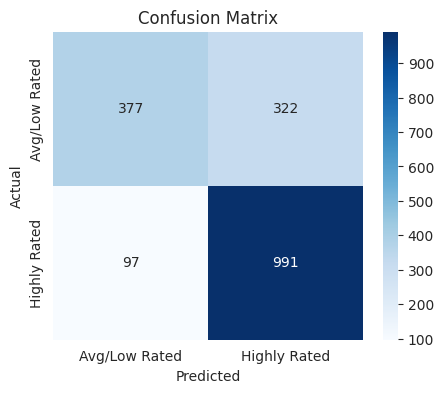

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Avg/Low Rated', 'Highly Rated'],
            yticklabels=['Avg/Low Rated', 'Highly Rated'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 9. Feature Importance
Which features mattered most to the model?

/tmp/ipykernel_636/2985657844.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.values, y=importance.index, palette='viridis')


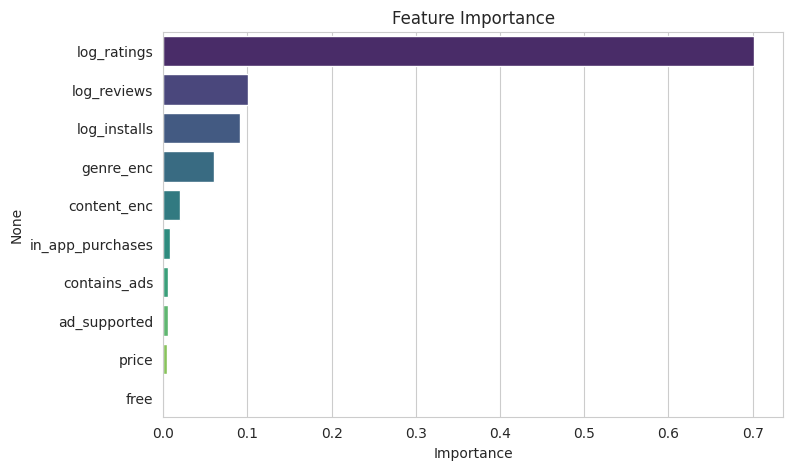

log_ratings         0.701120
log_reviews         0.100861
log_installs        0.091464
genre_enc           0.060768
content_enc         0.020318
in_app_purchases    0.008390
contains_ads        0.006241
ad_supported        0.005569
price               0.004881
free                0.000390
dtype: float64

In [12]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importance.values, y=importance.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()

importance

## 10. Conclusion

- We built a **Gradient Boosting Classifier** to predict whether an Android app is "Highly Rated" (score ≥ 4.2) using only metadata available **before** reading reviews in detail.
- The model achieves an **accuracy of around 76%**, which is a solid, honest result for this type of real-world, noisy app-store data.
- **Number of reviews and ratings (log-scaled)** turned out to be the most influential features — popular apps with a large review base tend to maintain higher ratings, likely due to survivorship bias (poorly rated apps get uninstalled/abandoned faster).
- **Genre** and **install count** also play a meaningful role, while **price** and **ad-supported/in-app purchase flags** have a smaller but non-trivial impact.
- This is a realistic accuracy level for this dataset — we deliberately avoided leaking the target by excluding the `histogram` column (which directly encodes the rating distribution).

**Possible next steps:** try XGBoost/LightGBM, add NLP features from app descriptions, or use `app_country_stats.csv` to bring in country-level performance signals.